## FCI algorithm on Sachs dataset

In [ ]:
!pip install pywhy_graphs  bnlearn pooch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━

In [ ]:
!git clone https://github.com/py-why/dodiscover.git
%cd dodiscover
!pip install -e .

Cloning into 'dodiscover'...
remote: Enumerating objects: 27333, done.
remote: Counting objects: 100% (519/519), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 27333 (delta 428), reused 376 (delta 375), pack-reused 26814 (from 2)
Receiving objects: 100% (27333/27333), 535.07 MiB | 20.09 MiB/s, done.
Resolving deltas: 100% (22510/22510), done.
/content/dodiscover
Obtaining file:///content/dodiscover
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for dodiscover (pyproject.toml) ... done
  Created wheel for dodiscover: filename=dodiscover-0.0.0.dev0-0.editable-py3-none-any.whl size=7269 sha256=7d014723d763c1c46bca3f54df42c812105da7f28b20157e9d5e9306c8cfca5e
  Stored in directory: /tmp/pip-ephem-wheel-cache-5w9dl152/wheels/4b/0c/4f/f9651264cf2244ae17fcbb55f8786a33543639e66650c15a6c
Succes

In [ ]:
from pywhy_graphs.viz import draw
from dodiscover.ci import GSquareCITest
from dodiscover import PsiFCI, Context, make_context, InterventionalContextBuilder

import pandas as pd
import bnlearn

import pooch

[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


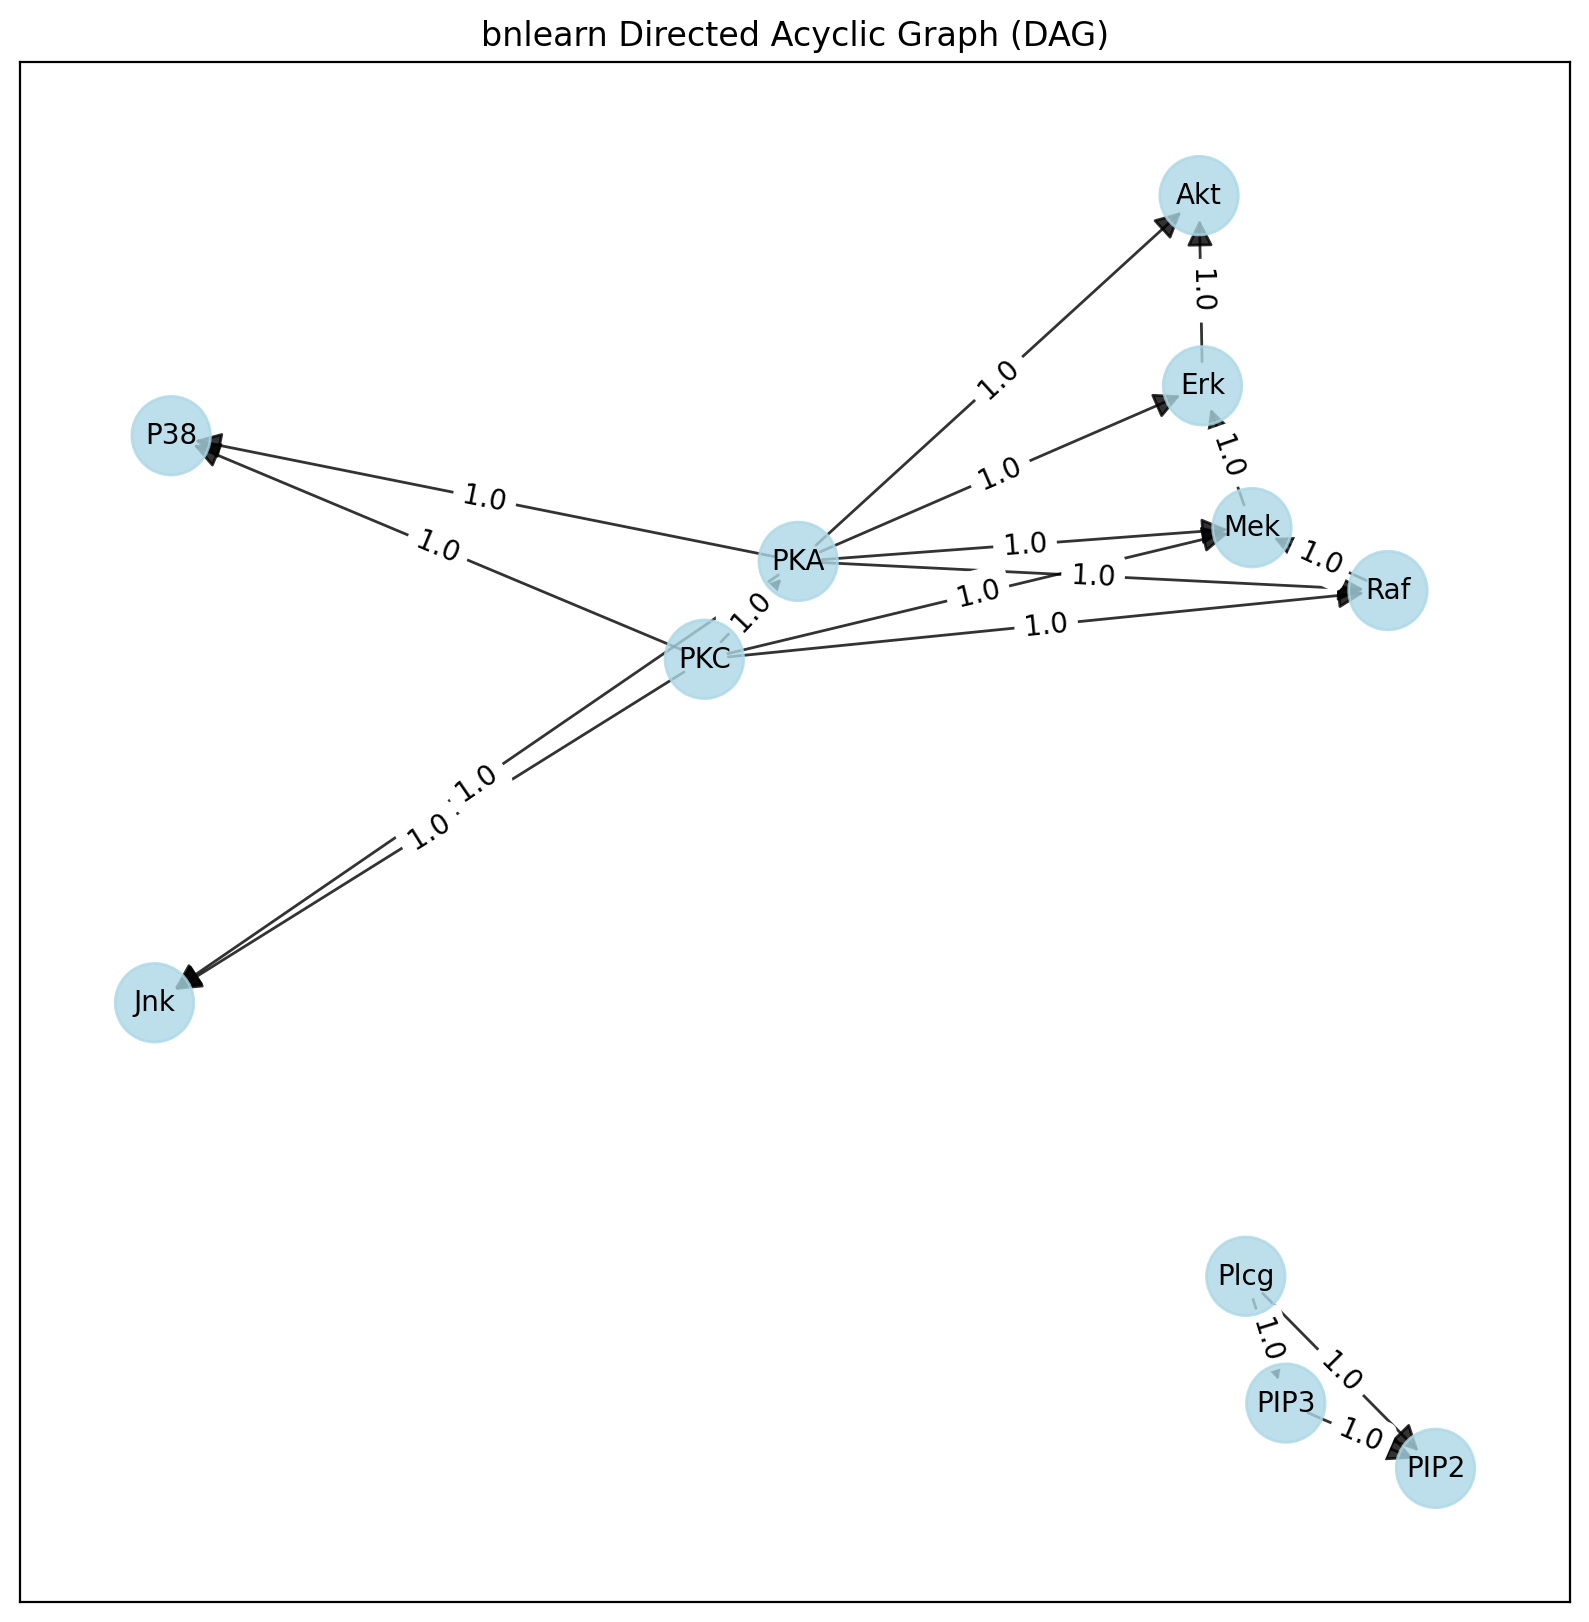

   Raf  Mek  Plcg  PIP2  PIP3  Erk  Akt  PKA  PKC  P38  Jnk  INT
0    1    1     1     2     3    2    1    3    1    2    1    8
1    1    1     1     1     3    3    2    3    1    2    1    8
2    1    1     2     2     3    2    1    3    2    1    1    8
3    1    1     1     1     3    2    1    3    1    3    1    8
4    1    1     1     1     3    2    1    3    1    1    1    8
(5400, 12)


In [ ]:
url = "https://www.bnlearn.com/book-crc/code/sachs.interventional.txt.gz"
file_path = pooch.retrieve(
    url=url,
    known_hash="md5:39ee257f7eeb94cb60e6177cf80c9544",
)

df = pd.read_csv(file_path, delimiter=" ")

ground_truth_dag = bnlearn.import_DAG("sachs", verbose=False)
fig = bnlearn.plot(ground_truth_dag)

print(df.head())
print(df.shape)

In [ ]:
unique_ints = df["INT"].unique()

intervention_targets = [df.columns[idx] for idx in unique_ints]
data_cols = [col for col in df.columns if col != "INT"]
data = []
for interv_idx in unique_ints:
    _data = df[df["INT"] == interv_idx][data_cols]
    data.append(_data)

print(len(data), len(intervention_targets))

6 6


In [ ]:
# our dataset is comprised of discrete valued data, so we will utilize the
# G^2 CI test.
ci_estimator = GSquareCITest(data_type="discrete")

# Since our data is entirely discrete, we can also use the G^2 test as our
# CD test.
cd_estimator = GSquareCITest(data_type="discrete")

alpha = 0.05
learner = PsiFCI(
    ci_estimator=ci_estimator,
    cd_estimator=cd_estimator,
    alpha=alpha,
    max_combinations=10,
    max_cond_set_size=4,
    n_jobs=-1,
)

# create context with information about the interventions
ctx_builder = make_context(create_using=InterventionalContextBuilder)
ctx: Context = (
    ctx_builder.variables(data=data[0]).num_distributions(6).obs_distribution(False).build()
)

print(ctx.init_graph)
print(ctx.f_nodes)

Graph with 26 nodes and 325 edges
[('F', 0), ('F', 1), ('F', 2), ('F', 3), ('F', 4), ('F', 5), ('F', 6), ('F', 7), ('F', 8), ('F', 9), ('F', 10), ('F', 11), ('F', 12), ('F', 13), ('F', 14)]


In [ ]:
learner = learner.learn_graph(data, ctx)

In [ ]:
est_pag = learner.graph_

print(f"There are {len(est_pag.to_undirected().edges)} edges in the resulting PAG")

There are 151 edges in the resulting PAG


In [ ]:
dot_graph = draw(est_pag, direction="LR")
dot_graph.render(outfile="psi_pag_full.png", view=True, cleanup=True)

'psi_pag_full.png'

In [ ]:
est_pag_no_fnodes = est_pag.subgraph(ctx.get_non_augmented_nodes())
dot_graph = draw(est_pag_no_fnodes, direction="LR")
dot_graph.render(outfile="psi_pag.png", view=True, cleanup=True)

'psi_pag.png'

### Evaluation

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# converting to undirected edge sets
true_edges = set(ground_truth_dag['model'].to_undirected().edges())
pred_edges = set(est_pag.to_undirected().edges())

# Ensure node names are strings and convert to lowercase
true_edges = set((str(u).lower(), str(v).lower()) for u, v in true_edges)
pred_edges = set((str(u).lower(), str(v).lower()) for u, v in pred_edges)


all_nodes = sorted(set([n for edge in true_edges.union(pred_edges) for n in edge]))
node_idx = {node: idx for idx, node in enumerate(all_nodes)}
n = len(all_nodes)

true_adj = [[0]*n for _ in range(n)]
pred_adj = [[0]*n for _ in range(n)]

for u, v in true_edges:
    i, j = node_idx[u], node_idx[v]
    true_adj[i][j] = true_adj[j][i] = 1

for u, v in pred_edges:
    i, j = node_idx[u], node_idx[v]
    pred_adj[i][j] = pred_adj[j][i] = 1

y_true = [true_adj[i][j] for i in range(n) for j in range(i+1, n)]
y_pred = [pred_adj[i][j] for i in range(n) for j in range(i+1, n)]

In [ ]:
# Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print("Evaluation Metrics on Sachs using PsiFCI:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")

Evaluation Metrics on Sachs using PsiFCI:
Precision: 0.0530
Recall:    0.4706
F1 Score:  0.0952
Accuracy:  0.5323


In [ ]:
import networkx as nx

def calculate_shd(ground_truth_dag, estimated_pag):
    # Get nodes from both graphs
    dag_nodes = set(ground_truth_dag['model'].nodes())
    pag_nodes = set(estimated_pag.nodes())

    # Find common nodes (intersection)
    common_nodes = dag_nodes.intersection(pag_nodes)

    if len(common_nodes) == 0:
        print("Warning: No common nodes found between DAG and PAG. SHD is 0.")
        return 0

    # Extract undirected edges for common nodes only
    true_edges = set()
    for u, v in ground_truth_dag['model'].to_undirected().edges():
        if u in common_nodes and v in common_nodes:
            # Normalize edge representation (smaller node first)
            true_edges.add(tuple(sorted((u, v))))

    pred_edges = set()
    for u, v in estimated_pag.to_undirected().edges():
        if isinstance(u, str) and isinstance(v, str) and u in common_nodes and v in common_nodes:
             # Normalize edge representation (smaller node first) and ensure nodes are strings
            pred_edges.add(tuple(sorted((u, v))))


    # Calculate differences in edge sets
    added_edges = pred_edges - true_edges
    deleted_edges = true_edges - pred_edges

    # SHD is the number of added and deleted edges
    shd = len(added_edges) + len(deleted_edges)

    print(f"Number of added edges (False Positives): {len(added_edges)}")
    print(f"Number of deleted edges (False Negatives): {len(deleted_edges)}")

    return shd

# Calculate the undirected SHD
shd_value = calculate_shd(ground_truth_dag, est_pag)

print(f"\nUndirected Structural Hamming Distance (SHD): {shd_value}")

Number of added edges (False Positives): 1
Number of deleted edges (False Negatives): 9

Undirected Structural Hamming Distance (SHD): 10
